In [1]:
# Repo-root bootstrap: find the directory containing the `llm_perf` package
# (walking up from CWD) and chdir there so paths like "llm_perf/database/..."
# and "assets/..." resolve regardless of where the notebook lives on disk.
import os
from pathlib import Path
_p = Path.cwd()
while not (_p / "llm_perf" / "__init__.py").exists():
    if _p == _p.parent:
        raise RuntimeError("Could not find llm_perf repo root from " + str(Path.cwd()))
    _p = _p.parent
os.chdir(_p)
print("cwd:", Path.cwd())

cwd: /Users/jasonlu/Projects/ai.cluster/llm_perf


# Partition-Optimal Pareto Frontiers vs. Framework Overhead

**Question:** how does a fixed per-decode-step framework overhead `t_oh` (CUDA graph replay, sampling, detokenization, scheduler tick) shift the (throughput/GPU, interactivity) Pareto frontier, and does it change which (PP, TP, EP, SP) partition wins?

**Method:** run the full partition × batch sweep once on the base hardware. Then, per overhead value, add `t_oh` to every step time post-hoc:

$$t_{step}^{eff} = t_{step}^{user} + t_{oh}$$

and rebuild the frontier from the shifted metrics:

$$\text{TPOT}^{eff} = t_{step}^{eff}, \quad \text{tput/GPU}^{eff} = \frac{B \cdot DP}{t_{step}^{eff} \cdot N_{dev}}, \quad \text{interactivity}^{eff} = 1 / t_{step}^{eff}$$

Small-B corners (high interactivity) are hit hardest — fewer tokens to amortize `t_oh` over. Large-B throughput corners barely move. The question is whether that asymmetric tax is enough to *re-order* the winning partitions at any corner.

Model, system, and tuner are configured in Section 1 — swap the database paths there to study a different setup.

## 1. Imports and spec loading

In [2]:
from __future__ import annotations

import math
from copy import deepcopy
from dataclasses import dataclass

import matplotlib.pyplot as plt

from llm_perf import InferenceCalculator
from llm_perf.core.kv_paging_model import KVPagingConfig, compute_kv_paging
from llm_perf.core.memory_model import compute_memory
from llm_perf.io import load_model_spec, load_system_spec, load_tuning_spec
from llm_perf.specs.partition_spec import PartitionSpec
from llm_perf.specs.system_spec import span_tiers

# Configuration — matches the NVIDIA inference blog (GPT-1.8T MoE @ FP4,
# GB200 NVL72). Swap these paths to study a different model/system.
MODEL = "llm_perf/database/model/gpt_1_8t_moe.json"
SYSTEM = "llm_perf/database/system/gb200.72gpu.json"
TUNER = "llm_perf/database/tuner/gpt_1_8t_moe.tuner.json"

S_DECODE = 8192
BPP_FP4 = 0.5  # GB200 inference precision.

model = load_model_spec(MODEL)
model.bytes_per_param = BPP_FP4
system = load_system_spec(SYSTEM)
tuner_base = load_tuning_spec(TUNER)
tuner_base.S_decode = S_DECODE
tuner_base.B_decode = 1

hbm_bw = system.device.hbm_bandwidth_GBps
base_alpha, base_bw, _ = span_tiers(system.get_tier_chain('TP'), 2)
peak_tf = system.device.peak_flops_TF
print(f"Model: {model.name}  L={model.L}  H={model.H}  n_kv={model.n_kv}  bytes/param={model.bytes_per_param}")
print(f"System: {system.num_devices} GPUs  HBM={hbm_bw:.0f} GB/s  peak={peak_tf:.0f} TF  scale-up={base_bw:.0f} GB/s · {base_alpha:.2f} μs")

Model: GPT-1.8T-MoE  L=120  H=20480  n_kv=16  bytes/param=0.5
System: 72 GPUs  HBM=8000 GB/s  peak=2250 TF  scale-up=900 GB/s · 0.50 μs


## 2. Partition enumeration

Constraints (from `llm_perf/utils/partition_enum.py` — `describe_constraints` printed below):

- **`PP ≤ 8`** — operational cap (matches `pareto_basic`). The library default is 32; this notebook pins `PP_MAX=8` for the typical PP-capped operational regime. Raise to study the unbounded case.
- `TP ≤ min(n_kv, n_experts)` (powers-of-2 ladder).
- `EP ≤ n_experts` (powers-of-2 ladder); `EP = 1` for dense.
- `TP · EP ≤ scale_up_domain` so heavy intra-layer collectives stay rack-local.
- `SP` sweeps `[1, 2, 4, 8, 16, 32, 64]`.
- `PP · TP · EP · SP ≤ num_devices`.


In [3]:
PP_MAX = 8   # Operational cap; raise to 32 to match unbounded-PP analysis.

from llm_perf.utils import (
    enumerate_partitions as _enumerate_partitions,
    describe_constraints,
)


def enumerate_partitions(num_devices: int) -> list[PartitionSpec]:
    """Local shim around llm_perf.utils.enumerate_partitions; pins (model, system, pp_max).

    Constraints applied: PP <= PP_MAX (set above; default 8 here, vs the
    library's 32);  TP <= min(n_kv, n_experts); EP <= n_experts (or 1 for dense);
    TP*EP <= scale_up_domain_size(system); SP <= 64 (ladder-based);
    PP*TP*EP*SP <= num_devices.
    See `llm_perf/utils/partition_enum.py` for the full derivation.
    """
    return _enumerate_partitions(model, system, num_devices=num_devices, pp_max=PP_MAX)


print(describe_constraints(model, system, pp_max=PP_MAX))

partitions = enumerate_partitions(system.num_devices)
print(f"Valid partitions: {len(partitions)}")


PP ≤ 8; TP ≤ min(n_kv=16, n_experts=16) = 16; EP ≤ n_experts=16; TP·EP ≤ scale_up=72 (tier_idx=0)
Valid partitions: 260


## 3. Partition sweep with post-hoc overhead

Each sample records the raw `t_step` from the inference calculator. An overhead is then added post-hoc to produce the frontier metrics — so the hardware sweep runs once per partition and is re-used across every `t_oh`.

In [4]:
@dataclass
class RawPoint:
    partition: PartitionSpec
    B: int
    t_step: float   # raw TPOT before overhead, seconds
    DP: int

    @property
    def part_label(self) -> str:
        p = self.partition
        return f"PP={p.PP} TP={p.TP} EP={p.EP} SP={p.SP}"


@dataclass
class Point:
    partition: PartitionSpec
    B: int
    tput_per_gpu: float
    interactivity: float
    TPOT_ms: float

    @property
    def part_label(self) -> str:
        p = self.partition
        return f"PP={p.PP} TP={p.TP} EP={p.EP} SP={p.SP}"


def log_spaced_batch_sizes(b_max: int) -> list[int]:
    if b_max <= 1:
        return [1]
    n = max(int(math.log10(b_max) * 10), 16)
    raw = {1, b_max}
    for i in range(n + 1):
        raw.add(max(1, int(round(10 ** (i * math.log10(b_max) / n)))))
    p = 1
    while p <= b_max:
        raw.add(p)
        p *= 2
    return sorted(raw)


def sweep_partition_raw(model, system, partition, tuner_base) -> list[RawPoint]:
    try:
        mem = compute_memory(model, system, partition, tuner_base)
    except Exception:
        return []
    paging = KVPagingConfig(block_size=16, beam_width=1, system_overhead_GB=1.5)
    kv = compute_kv_paging(model, system, partition, tuner_base, mem, paging)
    b_max = int(kv.max_sequences)
    if b_max < 1:
        return []
    replica = partition.PP * partition.TP * partition.EP * partition.SP
    DP = max(1, system.num_devices // replica)

    pts: list[RawPoint] = []
    for B in log_spaced_batch_sizes(b_max):
        tuner = deepcopy(tuner_base)
        tuner.B_decode = B
        try:
            r = InferenceCalculator(model, system, partition, tuner).run()
        except Exception:
            continue
        if r.latency.TPOT <= 0:
            continue
        pts.append(RawPoint(partition=partition, B=B, t_step=r.latency.TPOT, DP=DP))
    return pts


def apply_overhead(raw: list[RawPoint], t_oh_s: float,
                   num_devices: int) -> list[Point]:
    out: list[Point] = []
    for rp in raw:
        t_eff = rp.t_step + t_oh_s
        tput_per_gpu = (rp.B * rp.DP) / (t_eff * num_devices)
        out.append(Point(
            partition=rp.partition,
            B=rp.B,
            tput_per_gpu=tput_per_gpu,
            interactivity=1.0 / t_eff,
            TPOT_ms=t_eff * 1e3,
        ))
    return out


def pareto_frontier(points: list[Point]) -> list[Point]:
    sorted_pts = sorted(points, key=lambda p: (-p.tput_per_gpu, -p.interactivity))
    frontier: list[Point] = []
    best_interact = -math.inf
    for p in sorted_pts:
        if p.interactivity > best_interact + 1e-9:
            frontier.append(p)
            best_interact = p.interactivity
    frontier.sort(key=lambda p: p.tput_per_gpu)
    return frontier

## 4. Run the hardware sweep once, then re-price per `t_oh`

Overhead anchors map roughly onto today's serving-framework landscape. The numbers are order-of-magnitude estimates (vary with model size, hardware, and workload) meant to locate each stack on the frontier:

| `t_oh` | Framework regime |
|---|---|
| **0 μs** | Ideal / theoretical lower bound (no Python, no scheduler gap). Reference baseline. |
| **100 μs** | Highly tuned stack — TensorRT-LLM, SGLang, or vLLM v1 with CUDA graphs + persistent kernels + async scheduler. Per-step work is ~only graph launch + token append. |
| **500 μs** | Production vLLM v1 / well-tuned TGI with CUDA graphs + continuous batching + paged attention. Sampling and detokenization remain on the hot path. |
| **1 ms** | Vanilla vLLM v0 / default TGI. CUDA graphs partially used; per-step Python scheduler tick starts to show. |
| **2 ms** | Eager-mode serving (no graph capture) or heavy custom Python scheduler. Host-device sync visible per step. |
| **5 ms** | Unoptimized HF `transformers.generate()` loop — per-token Python dispatch, no batching tricks, sync detokenization. |

The hardware sweep runs once per partition; each `t_oh` anchor re-prices the cached `t_step` samples post-hoc.

In [5]:
# Overhead anchors (μs/step) → approximate serving-framework regime:
#     0     → ideal (no framework)
#   100     → TensorRT-LLM / SGLang / vLLM v1, graph-captured + persistent
#   500     → production vLLM / well-tuned TGI (graphs + continuous batching)
#  1000     → vLLM v0 / default TGI (partial graph capture)
#  2000     → eager-mode serving or heavy Python scheduler
#  5000     → unoptimized HF `generate()` loop
OVERHEAD_PER_STEP_US = [0, 100, 500, 1000, 2000, 5000]

print(f"Running hardware sweep once over {len(partitions)} partitions ...")
raw_all: list[RawPoint] = []
for part in partitions:
    raw_all.extend(sweep_partition_raw(model, system, part, tuner_base))
print(f"Collected {len(raw_all)} (partition, B) samples")

oh_frontiers: dict[str, list[Point]] = {}
for t_oh_us in OVERHEAD_PER_STEP_US:
    label = ("t_oh = 0 μs  (ideal)" if t_oh_us == 0
             else f"t_oh = {t_oh_us:,.0f} μs")
    pts = apply_overhead(raw_all, t_oh_us * 1e-6, system.num_devices)
    oh_frontiers[label] = pareto_frontier(pts)
    print(f"[t_oh] {label}")

print(f"\nFrontiers computed: {len(oh_frontiers)} overhead values")

Running hardware sweep once over 260 partitions ...
Collected 5895 (partition, B) samples
[t_oh] t_oh = 0 μs  (ideal)
[t_oh] t_oh = 100 μs
[t_oh] t_oh = 500 μs
[t_oh] t_oh = 1,000 μs
[t_oh] t_oh = 2,000 μs
[t_oh] t_oh = 5,000 μs

Frontiers computed: 6 overhead values


## 5. Winners summary

The question isn't whether the frontier moves (it will — overhead is a tax), but whether the *winning partition per corner* changes. If winners are stable across overheads, partition selection is decoupled from overhead reduction.

In [6]:
def winners(frontier: list[Point]) -> list[tuple[str, int]]:
    counts: dict[str, int] = {}
    for p in frontier:
        counts[p.part_label] = counts.get(p.part_label, 0) + 1
    return sorted(counts.items(), key=lambda kv: -kv[1])


for label, fr in oh_frontiers.items():
    w = winners(fr)
    top = ", ".join(f"{k} ({v})" for k, v in w)
    print(f"  {label}")
    print(f"    winners: {top}")

  t_oh = 0 μs  (ideal)
    winners: PP=8 TP=8 EP=1 SP=1 (33), PP=6 TP=4 EP=1 SP=1 (4)
  t_oh = 100 μs
    winners: PP=8 TP=8 EP=1 SP=1 (33), PP=6 TP=4 EP=1 SP=1 (4)
  t_oh = 500 μs
    winners: PP=8 TP=8 EP=1 SP=1 (33), PP=6 TP=4 EP=1 SP=1 (4)
  t_oh = 1,000 μs
    winners: PP=8 TP=8 EP=1 SP=1 (34), PP=6 TP=4 EP=1 SP=1 (4)
  t_oh = 2,000 μs
    winners: PP=8 TP=8 EP=1 SP=1 (34), PP=6 TP=4 EP=1 SP=1 (4)
  t_oh = 5,000 μs
    winners: PP=8 TP=8 EP=1 SP=1 (34), PP=6 TP=4 EP=1 SP=1 (4), PP=8 TP=4 EP=1 SP=1 (1)


## 6. Pareto plot

X = interactivity (1/TPOT), Y = throughput/GPU — NVIDIA-blog convention. Log-log so the low-interactivity / high-tput corner stays legible as `t_oh` grows.

Saved -> assets/pareto_vs_overhead.png


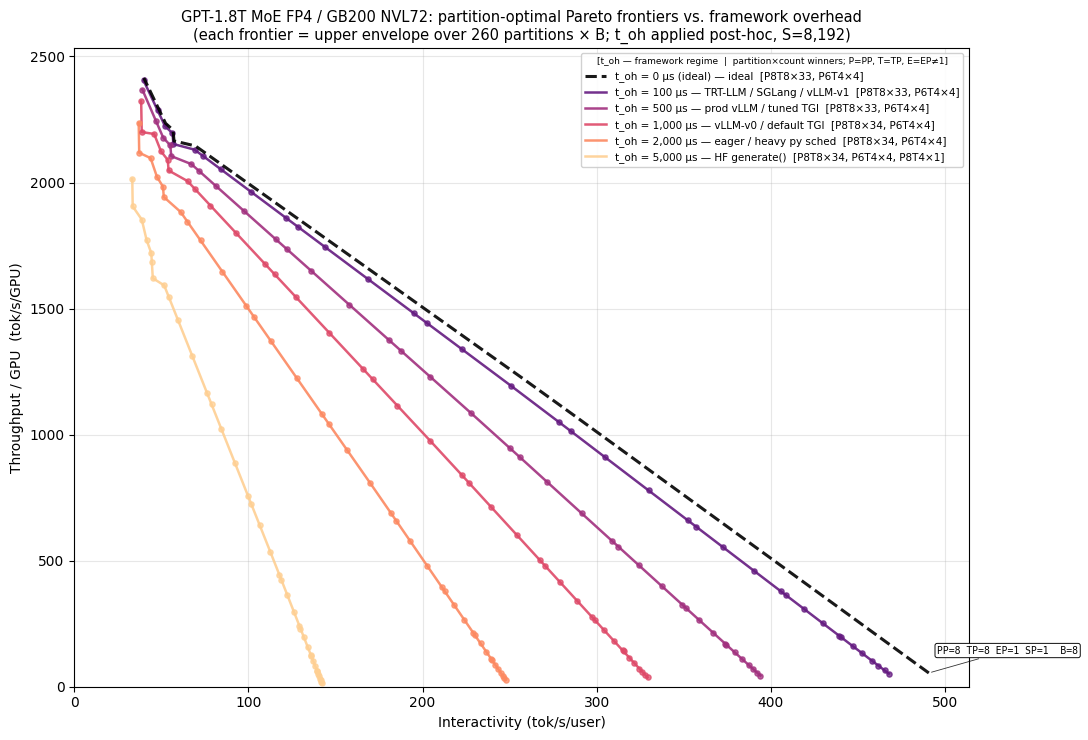

In [7]:
def winners_tag(frontier: list[Point]) -> str:
    """Compact label for legend: P=PP T=TP E=EP (drops EP=1 SP=1)."""
    counts: dict[str, int] = {}
    for p in frontier:
        counts[p.part_label] = counts.get(p.part_label, 0) + 1
    def short(name: str) -> str:
        return (name.replace(" EP=1", "").replace(" SP=1", "")
                    .replace("PP=", "P").replace("TP=", "T")
                    .replace("EP=", "E").replace(" ", ""))
    items = sorted(counts.items(), key=lambda kv: -kv[1])
    return ", ".join(f"{short(k)}×{v}" for k, v in items)


# Framework-regime annotation per t_oh anchor — kept short to fit the legend.
FRAMEWORK_TAG: dict[int, str] = {
    0:    "ideal",
    100:  "TRT-LLM / SGLang / vLLM-v1",
    500:  "prod vLLM / tuned TGI",
    1000: "vLLM-v0 / default TGI",
    2000: "eager / heavy py sched",
    5000: "HF generate()",
}


def annotate_ideal(ax, frontier, color="black"):
    if not frontier:
        return
    seen: set[str] = set()
    picks: list[int] = []
    for i, p in enumerate(frontier):
        if p.part_label not in seen:
            seen.add(p.part_label); picks.append(i)
    min_dx = 0.05 * max((p.interactivity for p in frontier), default=1.0)
    last_x = -math.inf
    kept: list[int] = []
    for idx in picks:
        x = frontier[idx].interactivity
        if x - last_x >= min_dx:
            kept.append(idx); last_x = x
    offsets = [(6, 14), (6, -20), (6, 32), (6, -38)]
    for j, idx in enumerate(kept):
        p = frontier[idx]
        dx, dy = offsets[j % len(offsets)]
        ax.annotate(
            f"{p.part_label}  B={p.B}",
            xy=(p.interactivity, p.tput_per_gpu),
            xytext=(dx, dy), textcoords="offset points",
            fontsize=7, family="monospace", color="black", ha="left",
            bbox=dict(boxstyle="round,pad=0.22", fc="white",
                      ec=color, alpha=0.95, lw=0.7),
            arrowprops=dict(arrowstyle="-", color=color, lw=0.6, alpha=0.8),
        )


fig, ax = plt.subplots(figsize=(11, 7.5))
cmap = plt.get_cmap("magma")
labels = list(oh_frontiers.keys())
colors = [cmap(0.15 + 0.75 * i / max(1, len(labels) - 1)) for i in range(len(labels))]


def legend_label(t_oh_us: int, fr: list[Point]) -> str:
    tag = FRAMEWORK_TAG.get(t_oh_us, "")
    head = ("t_oh = 0 μs (ideal)" if t_oh_us == 0
            else f"t_oh = {t_oh_us:,} μs")
    # "head — framework tag  [partition winners]"
    return f"{head} — {tag}  [{winners_tag(fr)}]"


# Zero-overhead reference as dashed black
zero_label = labels[0]
zero_frontier = oh_frontiers.get(zero_label, [])
if zero_frontier:
    ax.plot([p.interactivity for p in zero_frontier],
            [p.tput_per_gpu for p in zero_frontier],
            "--", lw=2.2, color="black", alpha=0.9,
            label=legend_label(0, zero_frontier), zorder=6)

for (label, fr), color, t_oh_us in zip(oh_frontiers.items(), colors, OVERHEAD_PER_STEP_US):
    if not fr or label == zero_label:
        continue
    ax.plot([p.interactivity for p in fr], [p.tput_per_gpu for p in fr],
            "-", lw=1.8, color=color, alpha=0.9,
            label=legend_label(t_oh_us, fr))
    ax.scatter([p.interactivity for p in fr], [p.tput_per_gpu for p in fr],
               s=14, color=color, alpha=0.75, zorder=3)

if zero_frontier:
    annotate_ideal(ax, zero_frontier, "black")

ax.set_xscale("linear"); ax.set_yscale("linear")
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.set_xlabel("Interactivity (tok/s/user)")
ax.set_ylabel("Throughput / GPU  (tok/s/GPU)")
ax.set_title(
    f"GPT-1.8T MoE FP4 / GB200 NVL72: partition-optimal Pareto frontiers vs. framework overhead\n"
    f"(each frontier = upper envelope over {len(partitions)} partitions × B; "
    f"t_oh applied post-hoc, S={S_DECODE:,})",
    fontsize=10.5,
)
ax.grid(True, which="both", alpha=0.3)
ax.legend(
    loc="upper right", fontsize=7.5, framealpha=0.9,
    title="[t_oh — framework regime  |  partition×count winners; P=PP, T=TP, E=EP≠1]",
    title_fontsize=6.5,
)
fig.tight_layout()
fig.savefig("assets/pareto_vs_overhead.png", dpi=130, bbox_inches="tight")
print("Saved -> assets/pareto_vs_overhead.png")
plt.show()

## 7. What to take away

- Overhead is an **asymmetric tax**: the high-interactivity corner (small B) retreats sharply because small B means few tokens to amortize `t_oh` over; the high-throughput corner (large B) is nearly untouched because `t_oh ≪ t_step` at saturation.
- At large `t_oh` the entire frontier collapses toward the right edge — every partition's interactivity is capped near `1 / t_oh` regardless of its raw step time.
- Despite this, the **winning partition at each corner is stable across overhead values**. Under the `PP ≤ 8` cap, `PP=8 TP=8 EP=1 SP=1` dominates 33–34 of 37 frontier corners at every `t_oh` from 0 → 5000 μs (with `PP=6 TP=4` rounding out the high-interactivity corner). Overhead ≪ partition choice: reducing `t_oh` shifts you along the frontier, but doesn't change which partition you should pick at a given batch.
- If you're picking a partition to hit a latency SLO near the interactivity corner, **budget for `t_oh` first** — it's often the largest single contributor to TPOT at small B.
